# 01 - Data Understanding

Day 1, step 1. No modelling here. The goal is to load every dataset and answer the
same five questions for each: how big is it, what is in it, what is missing, what is
the primary key, and what can it join to.

Rule from the build notes: **do not merge anything yet**, even where two files look
like they share an ID. A matching column name is not proof of a matching key - that
gets confirmed in notebook 04.

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

from app.utils.config import RAW_FILES

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Raw files present:")
for name, path in RAW_FILES.items():
    status = f"{path.stat().st_size / 1_000_000:.2f} MB" if path.exists() else "MISSING"
    print(f"  {name:20s} {path.name:35s} {status}")

Raw files present:
  attrition            employee_attrition.csv              0.23 MB
  engagement           hr_performance_engagement.csv       0.12 MB
  occupation           occupation_data.csv                 0.27 MB
  essential_skills     essential_skills.csv                2.33 MB
  software_skills      software_skills.csv                 3.56 MB
  role_requirements    role_skill_requirements.csv         0.01 MB
  employee_skills      employee_current_skills.csv         0.56 MB


## Load everything

`employee_attrition.csv` ships with a UTF-8 BOM, so it needs `encoding='utf-8-sig'`
or the first column name comes back as `﻿Age`.

In [2]:
datasets = {}
datasets["attrition"] = pd.read_csv(RAW_FILES["attrition"], encoding="utf-8-sig")
datasets["attrition"].columns = [c.strip() for c in datasets["attrition"].columns]
for key in ["engagement", "occupation", "essential_skills", "software_skills",
            "role_requirements", "employee_skills"]:
    datasets[key] = pd.read_csv(RAW_FILES[key])

for name, df in datasets.items():
    print(f"{name:20s} {df.shape[0]:>7,} rows x {df.shape[1]:>2} cols")

attrition              1,470 rows x 35 cols
engagement             1,470 rows x 12 cols
occupation             1,016 rows x  3 cols
essential_skills      18,200 rows x 15 cols
software_skills       31,821 rows x  7 cols
role_requirements        162 rows x  7 cols
employee_skills       12,388 rows x  5 cols


## The standard checklist, applied to every dataset

Shape, dtypes, missingness, duplicates, and candidate identifier columns.

In [3]:
def profile(name: str, df: pd.DataFrame) -> dict:
    id_cols = [c for c in df.columns if "id" in c.lower() or "code" in c.lower()]
    unique_ids = [c for c in id_cols if df[c].is_unique]
    return {
        "dataset": name,
        "rows": len(df),
        "cols": df.shape[1],
        "missing_cells": int(df.isnull().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "numeric_cols": int(df.select_dtypes("number").shape[1]),
        "object_cols": int(df.select_dtypes("object").shape[1]),
        "id_candidates": ", ".join(id_cols[:3]) or "-",
        "unique_key": ", ".join(unique_ids[:2]) or "(composite or none)",
    }


summary = pd.DataFrame([profile(n, d) for n, d in datasets.items()])
summary

,dataset,rows,cols,missing_cells,duplicate_rows,numeric_cols,object_cols,id_candidates,unique_key
0,attrition,1470,35,0,0,26,9,-,(composite or none)
1,engagement,1470,12,0,0,9,3,EmployeeID,EmployeeID
2,occupation,1016,3,0,0,0,3,O*NET-SOC Code,O*NET-SOC Code
3,essential_skills,18200,15,9100,0,5,10,"O*NET-SOC Code, Element ID, Scale ID",(composite or none)
4,software_skills,31821,7,0,0,0,7,"O*NET-SOC Code, Element ID",(composite or none)
5,role_requirements,162,7,0,0,2,5,ONET_SOC_Code,(composite or none)
6,employee_skills,12388,5,0,0,2,3,EmployeeID,(composite or none)


Nothing is missing anywhere, and no dataset has a fully duplicated row. That is
unusual for HR data and worth stating explicitly rather than assuming.

## The attrition dataset in detail

This is the one that feeds the ML model, so it gets the closest look.

In [4]:
emp = datasets["attrition"]
print("Shape:", emp.shape)
emp.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Target balance

This number decides how the model is evaluated later.

In [6]:
balance = emp["Attrition"].value_counts()
balance_pct = (emp["Attrition"].value_counts(normalize=True) * 100).round(2)
print(pd.DataFrame({"count": balance, "percent": balance_pct}))
print(f"\nImbalance ratio: {balance['No'] / balance['Yes']:.2f} stayers per leaver")

           count  percent
Attrition                
No          1233    83.88
Yes          237    16.12

Imbalance ratio: 5.20 stayers per leaver


**16% attrition.** A model that predicts "No" for everyone scores 84% accuracy while
being completely useless. Accuracy is therefore off the table as an evaluation
metric from here on - notebooks 06 and 07 use precision, recall, F1 and ROC-AUC.

### Columns that carry no information

In [7]:
constant_cols = [c for c in emp.columns if emp[c].nunique() == 1]
print("Zero-variance columns:", constant_cols)
for c in constant_cols:
    print(f"  {c:20s} always = {emp[c].iloc[0]!r}")

Zero-variance columns: ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount        always = np.int64(1)
  Over18               always = 'Y'
  StandardHours        always = np.int64(80)


These three get dropped in cleaning. They cannot help a model and they add
meaningless columns to the one-hot encoder.

### Identifier check

In [8]:
print("Columns containing 'id':", [c for c in emp.columns if "id" in c.lower()])
print("EmployeeNumber unique:", emp["EmployeeNumber"].is_unique)
print("EmployeeNumber range :", emp["EmployeeNumber"].min(), "-", emp["EmployeeNumber"].max())

Columns containing 'id': []
EmployeeNumber unique: True
EmployeeNumber range : 1 - 2068


**Finding that contradicts the plan.** The build notes assume the key is called
`EmployeeID`. The real IBM extract calls it `EmployeeNumber`, and there is no
`EmployeeID` column at all. Cleaning renames it, so every downstream notebook can
use the name the notes expect.

Note also that `EmployeeNumber` runs to 2068 across only 1,470 rows - the IDs are
sparse, not a contiguous 1..N range. Anything that assumes `EmployeeID == row index`
would be wrong.

### Distribution of the key numeric drivers

In [9]:
numeric_focus = ["Age", "MonthlyIncome", "YearsAtCompany", "TotalWorkingYears",
                 "DistanceFromHome", "YearsSinceLastPromotion"]
emp[numeric_focus].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.92,9.14,18.0,30.0,36.0,43.0,60.0
MonthlyIncome,1470.0,6502.93,4707.96,1009.0,2911.0,4919.0,8379.0,19999.0
YearsAtCompany,1470.0,7.01,6.13,0.0,3.0,5.0,9.0,40.0
TotalWorkingYears,1470.0,11.28,7.78,0.0,6.0,10.0,15.0,40.0
DistanceFromHome,1470.0,9.19,8.11,1.0,2.0,7.0,14.0,29.0
YearsSinceLastPromotion,1470.0,2.19,3.22,0.0,0.0,1.0,3.0,15.0


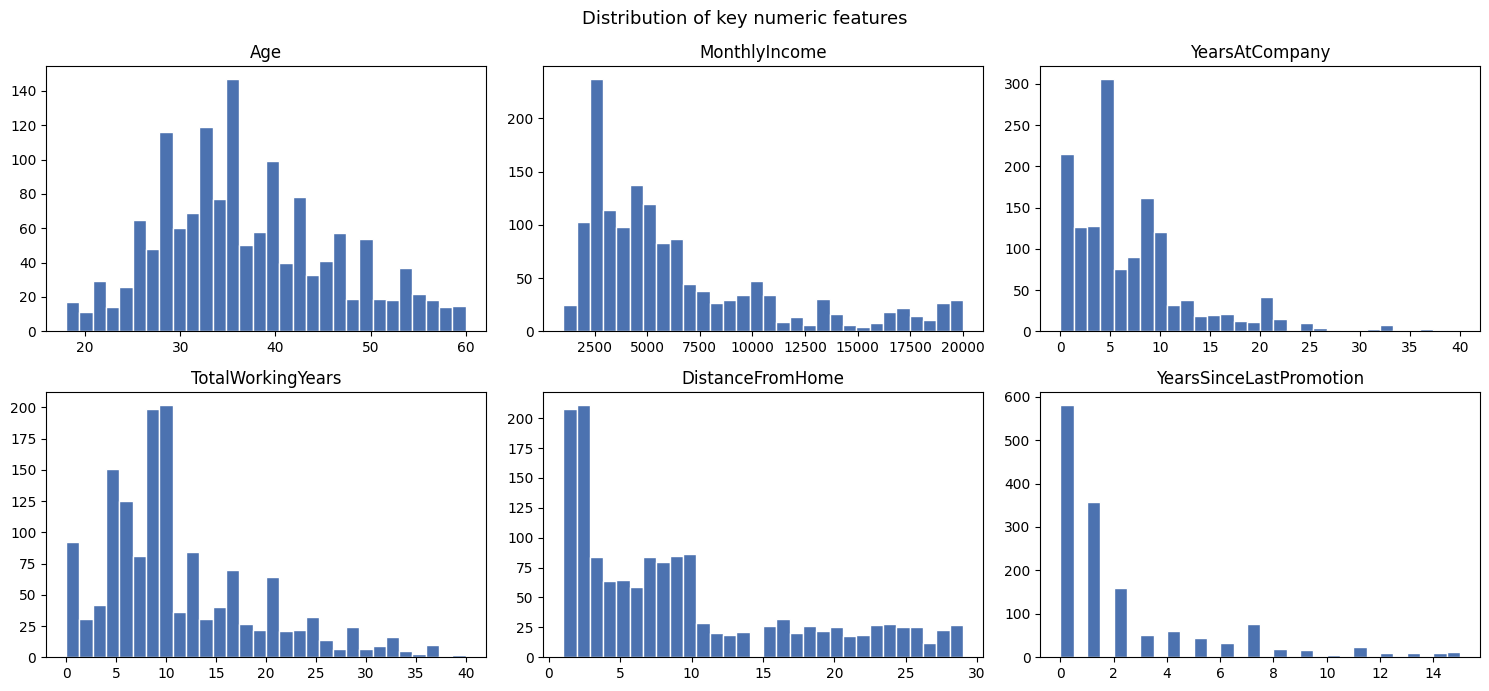

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), numeric_focus):
    ax.hist(emp[col], bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
fig.suptitle("Distribution of key numeric features", fontsize=13)
fig.tight_layout()
plt.show()

`MonthlyIncome`, `YearsAtCompany` and `TotalWorkingYears` are strongly right-skewed.
Those long tails are real senior employees, not data errors - which matters when
deciding what to do about "outliers" in notebook 03.

### Attrition rate by category

A first look at which groups actually leave, before any modelling.

In [11]:
for col in ["Department", "JobRole", "OverTime", "BusinessTravel", "MaritalStatus"]:
    rate = (emp.groupby(col)["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
            .sort_values(ascending=False).round(1))
    print(f"\n--- Attrition rate (%) by {col} ---")
    print(rate.to_string())


--- Attrition rate (%) by Department ---
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8

--- Attrition rate (%) by JobRole ---
JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Manufacturing Director        6.9
Healthcare Representative     6.9
Manager                       4.9
Research Director             2.5

--- Attrition rate (%) by OverTime ---
OverTime
Yes    30.5
No     10.4

--- Attrition rate (%) by BusinessTravel ---
BusinessTravel
Travel_Frequently    24.9
Travel_Rarely        15.0
Non-Travel            8.0

--- Attrition rate (%) by MaritalStatus ---
MaritalStatus
Single      25.5
Married     12.5
Divorced    10.1


`OverTime` stands out immediately: employees working overtime leave at roughly three
times the rate of those who do not. Sales Representatives and Laboratory Technicians
are the highest-risk roles. Both should show up in the SHAP analysis in notebook 08 -
if they do not, something is wrong with the model.

## The engagement dataset

In [12]:
eng = datasets["engagement"]
print(eng.shape)
eng.head()

(1470, 12)


,EmployeeID,Department,JobRole,ReviewPeriod,EngagementScore,JobSatisfactionScore,JobInvolvementScore,EnvironmentSatisfactionScore,WorkLifeBalanceScore,RelationshipSatisfactionScore,PerformanceRating,TrainingTimesLastYear
0,1,Sales,Sales Executive,2026-H1,53.3,100.0,66.7,33.3,0.0,0.0,3,0
1,2,Research & Development,Research Scientist,2026-H1,51.7,33.3,33.3,66.7,66.7,100.0,4,3
2,4,Research & Development,Laboratory Technician,2026-H1,61.7,66.7,33.3,100.0,66.7,33.3,3,3
3,5,Research & Development,Research Scientist,2026-H1,73.4,66.7,66.7,100.0,66.7,66.7,3,3
4,7,Research & Development,Laboratory Technician,2026-H1,46.7,33.3,66.7,0.0,66.7,100.0,3,3


In [13]:
eng[["EngagementScore", "JobSatisfactionScore", "PerformanceRating"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
EngagementScore,1470.0,57.70,15.22,8.3,48.3,58.3,68.4,100.0
JobSatisfactionScore,1470.0,57.62,36.77,0.0,33.3,66.7,100.0,100.0
PerformanceRating,1470.0,3.15,0.36,3.0,3.0,3.0,3.0,4.0


> **Provenance.** This file is derived from the IBM satisfaction/involvement columns
> for the same 1,470 employees, because the Kaggle original needs API credentials.
> See `scripts/build_derived_sources.py`. It is therefore a deterministic function of
> columns the attrition model also uses, which is exactly why it is kept for
> analytics only and never fed back in as a model feature.

## The O*NET reference datasets

In [14]:
occ = datasets["occupation"]
print("occupation_data:", occ.shape)
print("SOC code unique:", occ["O*NET-SOC Code"].is_unique)
occ.head(3)

occupation_data: (1016, 3)
SOC code unique: True


,O*NET-SOC Code,Title,Description
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh..."
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ..."


In [15]:
ess = datasets["essential_skills"]
print("essential_skills:", ess.shape)
print("Scale IDs present:", ess["Scale ID"].unique(), " <- IM = Importance, LV = Level")
print("Rows flagged Recommend Suppress = Y:", int((ess["Recommend Suppress"] == "Y").sum()))
ess.head(3)

essential_skills: (18200, 15)
Scale IDs present: ['IM' 'LV']  <- IM = Importance, LV = Level
Rows flagged Recommend Suppress = Y: 21


,O*NET-SOC Code,Title,Element ID,Element Name,Scale ID,Scale Name,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source
0,11-1011.00,Chief Executives,2.A.1.a,Reading Comprehension,IM,Importance,4.12,8,0.125,3.8800,4.3700,N,NaN,08/2023,Analyst
1,11-1011.00,Chief Executives,2.A.1.a,Reading Comprehension,LV,Level,4.62,8,0.183,4.2664,4.9836,N,N,08/2023,Analyst
2,11-1011.00,Chief Executives,2.A.1.b,Active Listening,IM,Importance,4.00,8,0.000,4.0000,4.0000,N,NaN,08/2023,Analyst


Two things to handle in cleaning: keep only the `IM` (Importance) rows, since Level
answers a different question, and drop the rows O*NET itself recommends suppressing
as statistically unreliable.

In [16]:
soft = datasets["software_skills"]
print("software_skills:", soft.shape)
print("distinct tools (Workplace Example):", soft["Workplace Example"].nunique())
print("distinct categories (Element Name):", soft["Element Name"].nunique())
soft.head(3)

software_skills: (31821, 7)
distinct tools (Workplace Example): 8753
distinct categories (Element Name): 134


,O*NET-SOC Code,Title,Workplace Example,Element ID,Element Name,Hot Technology,In Demand
0,11-1011.00,Chief Executives,Adobe Acrobat,2.E.5.b,Document management software,Y,N
1,11-1011.00,Chief Executives,AdSense Tracker,2.E.6.f,Data base user interface and query software,N,N
2,11-1011.00,Chief Executives,Atlassian JIRA,2.E.5.a,Content workflow software,Y,N


### Messy skill names - the problem the notes call out

In [17]:
messy = sorted(soft[soft["Workplace Example"].str.contains(
    "Amazon Web|Micosoft|SAP|Salesforce", case=False, na=False)]["Workplace Example"].unique())
for m in messy[:12]:
    print(" ", m)

Amazon Web Services AWS CloudFormation
  Amazon Web Services AWS SageMaker
  Amazon Web Services AWS software
  Breault Research ASAP
  Chesapeake Interlink Needles
  ClassApps SelectSurveyASP
  GE Fanuc Automation VersaPro
  Gale Expanded Academic ASAP PLUS
  Micosoft SQL Server Analysis Services SSAS
  SAP APO
  SAP Adaptive Server Enterprise
  SAP Americas mySAP ERP Human Capital Management HCM


`Micosoft SQL Server Analysis Services SSAS` is a genuine typo in the upstream O*NET
data, and `... software` suffixes are applied inconsistently. Left alone, these split
one real skill across several names and the gap engine over-counts. Handled in
notebook 03 by `app.services.skill_normalizer`.

## What each dataset is for

| Dataset | Purpose | Joins to |
|---|---|---|
| `employee_attrition` | feeds the attrition ML model | engagement (EmployeeID), roles (JobRole) |
| `hr_performance_engagement` | engagement analytics, no ML | attrition (EmployeeID) |
| `occupation_data` | role master reference | role requirements (SOC code) |
| `essential_skills` | required soft skills per role | occupation (SOC code) |
| `software_skills` | required tools per role | occupation (SOC code) |
| `role_skill_requirements` | the two skill files, resolved per JobRole | employees (JobRole) |
| `employee_current_skills` | what each employee already has | attrition (EmployeeID) |

Carried into notebook 02: the key is `EmployeeNumber` not `EmployeeID`, three columns
are constant, the target is 16% positive, and skill names need canonicalising.